In [46]:
# Machine Learning Project
## Title: Daily Income Prediction for Bodaboda Riders in Tanzania

### Objective
#The objective of this project is to design, train, evaluate, and deploy a machine learning model
#that predicts the daily income of bodaboda riders in Tanzania based on working conditions and
#environmental factors.


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [48]:
#disaplay working directory
cwd = os.getcwd()
print(cwd)

C:\Users\HP\Desktop\project


In [49]:
#import data file
df = pd.read_csv("bodaboda_daily_income.csv")
print(df)

    hours_worked  fuel_cost_tzs  distance_km rainy_day road_condition  \
0            NaN            NaN          126       Yes            NaN   
1            7.0        10360.0          171        No           Good   
2           11.0         8859.0           68       Yes           Poor   
3            8.0        10331.0           75       Yes           Poor   
4            NaN            NaN          126        No            NaN   
..           ...            ...          ...       ...            ...   
70          11.0        11742.0          167        No           Poor   
71           8.0         4863.0           78       Yes           Poor   
72           5.0         6790.0          121        No           Good   
73           8.0        11408.0          143       Yes           Fair   
74          11.0         4563.0          168        No           Good   

   location_type  daily_income_tzs  
0          Urban             28407  
1     Semi-Urban             22805  
2          R

In [50]:
df.head()

,hours_worked,fuel_cost_tzs,distance_km,rainy_day,road_condition,location_type,daily_income_tzs
0,NaN,NaN,126,Yes,NaN,Urban,28407
1,7.0,10360.0,171,No,Good,Semi-Urban,22805
2,11.0,8859.0,68,Yes,Poor,Rural,20237
3,8.0,10331.0,75,Yes,Poor,Semi-Urban,31943
4,NaN,NaN,126,No,NaN,Rural,27775


In [51]:
df.tail()

,hours_worked,fuel_cost_tzs,distance_km,rainy_day,road_condition,location_type,daily_income_tzs
70,11.0,11742.0,167,No,Poor,Semi-Urban,26338
71,8.0,4863.0,78,Yes,Poor,Semi-Urban,15412
72,5.0,6790.0,121,No,Good,Urban,22543
73,8.0,11408.0,143,Yes,Fair,Rural,22587
74,11.0,4563.0,168,No,Good,Semi-Urban,15728


In [52]:
df.shape #dimensions

(75, 7)

In [53]:
df.dtypes #datatypes

hours_worked        float64
fuel_cost_tzs       float64
distance_km           int64
rainy_day            object
road_condition       object
location_type        object
daily_income_tzs      int64
dtype: object

In [54]:

df.info() #essential details

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hours_worked      72 non-null     float64
 1   fuel_cost_tzs     72 non-null     float64
 2   distance_km       75 non-null     int64  
 3   rainy_day         75 non-null     object 
 4   road_condition    72 non-null     object 
 5   location_type     75 non-null     object 
 6   daily_income_tzs  75 non-null     int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 4.2+ KB


In [55]:
df.isnull().sum() #sum of missing values in each column

hours_worked        3
fuel_cost_tzs       3
distance_km         0
rainy_day           0
road_condition      3
location_type       0
daily_income_tzs    0
dtype: int64

In [56]:
#Getting matrix for features(X for independent variable and Y for dependent variable)
X = df.iloc[:,:-1].values #all columns except the last column
Y = df.iloc[:, 6:7].values # the last column only 
#.values convert the df into numpy array 

In [57]:
print(X)

[[nan nan 126 'Yes' nan 'Urban']
 [7.0 10360.0 171 'No' 'Good' 'Semi-Urban']
 [11.0 8859.0 68 'Yes' 'Poor' 'Rural']
 [8.0 10331.0 75 'Yes' 'Poor' 'Semi-Urban']
 [nan nan 126 'No' nan 'Rural']
 [13.0 4492.0 110 'Yes' 'Good' 'Semi-Urban']
 [6.0 11208.0 125 'Yes' 'Fair' 'Urban']
 [10.0 9276.0 67 'No' 'Good' 'Urban']
 [11.0 6062.0 105 'No' 'Fair' 'Semi-Urban']
 [8.0 7884.0 84 'Yes' 'Fair' 'Rural']
 [nan nan 126 'Yes' nan 'Urban']
 [11.0 6568.0 173 'No' 'Fair' 'Urban']
 [8.0 9056.0 126 'No' 'Poor' 'Urban']
 [6.0 9248.0 67 'No' 'Poor' 'Semi-Urban']
 [9.0 6027.0 147 'No' 'Good' 'Semi-Urban']
 [8.0 6695.0 83 'Yes' 'Fair' 'Rural']
 [5.0 5495.0 123 'No' 'Good' 'Rural']
 [11.0 11230.0 69 'No' 'Good' 'Rural']
 [9.0 9258.0 114 'Yes' 'Fair' 'Semi-Urban']
 [5.0 9618.0 167 'No' 'Poor' 'Semi-Urban']
 [8.0 10736.0 131 'Yes' 'Fair' 'Rural']
 [4.0 4391.0 168 'No' 'Poor' 'Rural']
 [13.0 9794.0 160 'No' 'Good' 'Semi-Urban']
 [9.0 8514.0 66 'No' 'Poor' 'Rural']
 [12.0 10432.0 160 'Yes' 'Poor' 'Urban']
 [4.0 

In [58]:
print(Y)

[[28407]
 [22805]
 [20237]
 [31943]
 [27775]
 [31244]
 [28184]
 [18343]
 [28500]
 [24662]
 [31964]
 [30125]
 [23130]
 [34531]
 [16679]
 [18506]
 [28284]
 [22253]
 [34128]
 [24435]
 [26310]
 [28296]
 [33525]
 [28245]
 [26151]
 [25457]
 [17479]
 [19452]
 [20881]
 [29069]
 [17849]
 [22390]
 [26922]
 [17489]
 [24823]
 [24207]
 [24540]
 [31364]
 [19611]
 [34223]
 [20878]
 [31347]
 [15851]
 [33071]
 [21833]
 [26938]
 [17427]
 [19000]
 [20052]
 [17738]
 [20387]
 [23002]
 [20536]
 [28479]
 [18913]
 [32450]
 [25636]
 [20726]
 [18373]
 [27161]
 [17082]
 [31281]
 [30305]
 [24817]
 [26261]
 [15417]
 [23808]
 [18267]
 [32209]
 [20745]
 [26338]
 [15412]
 [22543]
 [22587]
 [15728]]


In [59]:
#Data Preprocessing
#Input missing values
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer(strategy = "mean", missing_values = np.nan)
imputer2 = SimpleImputer(strategy = "mean", missing_values = np.nan)
imputer3 = SimpleImputer(strategy = "most_frequent", missing_values = np.nan)
X[:,:1] = imputer1.fit_transform(X[:, :1]) 
X[:,1:2] = imputer2.fit_transform(X[:,1:2])
X[:,4:5] = imputer3.fit_transform(X[:,4:5])


In [60]:
print(X)

[[8.541666666666666 8537.402777777777 126 'Yes' 'Poor' 'Urban']
 [7.0 10360.0 171 'No' 'Good' 'Semi-Urban']
 [11.0 8859.0 68 'Yes' 'Poor' 'Rural']
 [8.0 10331.0 75 'Yes' 'Poor' 'Semi-Urban']
 [8.541666666666666 8537.402777777777 126 'No' 'Poor' 'Rural']
 [13.0 4492.0 110 'Yes' 'Good' 'Semi-Urban']
 [6.0 11208.0 125 'Yes' 'Fair' 'Urban']
 [10.0 9276.0 67 'No' 'Good' 'Urban']
 [11.0 6062.0 105 'No' 'Fair' 'Semi-Urban']
 [8.0 7884.0 84 'Yes' 'Fair' 'Rural']
 [8.541666666666666 8537.402777777777 126 'Yes' 'Poor' 'Urban']
 [11.0 6568.0 173 'No' 'Fair' 'Urban']
 [8.0 9056.0 126 'No' 'Poor' 'Urban']
 [6.0 9248.0 67 'No' 'Poor' 'Semi-Urban']
 [9.0 6027.0 147 'No' 'Good' 'Semi-Urban']
 [8.0 6695.0 83 'Yes' 'Fair' 'Rural']
 [5.0 5495.0 123 'No' 'Good' 'Rural']
 [11.0 11230.0 69 'No' 'Good' 'Rural']
 [9.0 9258.0 114 'Yes' 'Fair' 'Semi-Urban']
 [5.0 9618.0 167 'No' 'Poor' 'Semi-Urban']
 [8.0 10736.0 131 'Yes' 'Fair' 'Rural']
 [4.0 4391.0 168 'No' 'Poor' 'Rural']
 [13.0 9794.0 160 'No' 'Good' 'Semi

In [61]:
#Encoding Categorical data(Class Label)
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
X[:,3] = label_encoder.fit_transform(X[:,3]) # labels on rainy_day

In [62]:
print(X[:,3])

[1 0 1 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 1 1 1 0 0 1 0
 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1
 0]


In [63]:
#Encoding categorical data(ordinal features)  <road_condition>
from sklearn.preprocessing import OrdinalEncoder
rank_order = [["Poor", "Fair", "Good"]]
ordinal_encoder = OrdinalEncoder(categories=rank_order)
X[:, 4:5] = ordinal_encoder.fit_transform(X[:, 4:5])  


In [64]:
print(X[:,4:5])

[[0.0]
 [2.0]
 [0.0]
 [0.0]
 [0.0]
 [2.0]
 [1.0]
 [2.0]
 [1.0]
 [1.0]
 [0.0]
 [1.0]
 [0.0]
 [0.0]
 [2.0]
 [1.0]
 [2.0]
 [2.0]
 [1.0]
 [0.0]
 [1.0]
 [0.0]
 [2.0]
 [0.0]
 [0.0]
 [0.0]
 [2.0]
 [2.0]
 [0.0]
 [0.0]
 [1.0]
 [0.0]
 [1.0]
 [0.0]
 [1.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [1.0]
 [0.0]
 [2.0]
 [2.0]
 [0.0]
 [2.0]
 [0.0]
 [0.0]
 [2.0]
 [0.0]
 [2.0]
 [1.0]
 [0.0]
 [1.0]
 [2.0]
 [1.0]
 [1.0]
 [2.0]
 [1.0]
 [1.0]
 [2.0]
 [0.0]
 [2.0]
 [0.0]
 [2.0]
 [2.0]
 [1.0]
 [1.0]
 [1.0]
 [0.0]
 [0.0]
 [0.0]
 [2.0]
 [1.0]
 [2.0]]


In [65]:
#Encoding categorical data (nominal features) <location_type>
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder(handle_unknown='ignore')
encoder_X = pd.DataFrame(onehot_encoder.fit_transform(X[:,5:6]).toarray())
X=np.column_stack((encoder_X, X))

In [66]:
print(X)

[[0.0 0.0 1.0 8.541666666666666 8537.402777777777 126 1 0.0 'Urban']
 [0.0 1.0 0.0 7.0 10360.0 171 0 2.0 'Semi-Urban']
 [1.0 0.0 0.0 11.0 8859.0 68 1 0.0 'Rural']
 [0.0 1.0 0.0 8.0 10331.0 75 1 0.0 'Semi-Urban']
 [1.0 0.0 0.0 8.541666666666666 8537.402777777777 126 0 0.0 'Rural']
 [0.0 1.0 0.0 13.0 4492.0 110 1 2.0 'Semi-Urban']
 [0.0 0.0 1.0 6.0 11208.0 125 1 1.0 'Urban']
 [0.0 0.0 1.0 10.0 9276.0 67 0 2.0 'Urban']
 [0.0 1.0 0.0 11.0 6062.0 105 0 1.0 'Semi-Urban']
 [1.0 0.0 0.0 8.0 7884.0 84 1 1.0 'Rural']
 [0.0 0.0 1.0 8.541666666666666 8537.402777777777 126 1 0.0 'Urban']
 [0.0 0.0 1.0 11.0 6568.0 173 0 1.0 'Urban']
 [0.0 0.0 1.0 8.0 9056.0 126 0 0.0 'Urban']
 [0.0 1.0 0.0 6.0 9248.0 67 0 0.0 'Semi-Urban']
 [0.0 1.0 0.0 9.0 6027.0 147 0 2.0 'Semi-Urban']
 [1.0 0.0 0.0 8.0 6695.0 83 1 1.0 'Rural']
 [1.0 0.0 0.0 5.0 5495.0 123 0 2.0 'Rural']
 [1.0 0.0 0.0 11.0 11230.0 69 0 2.0 'Rural']
 [0.0 1.0 0.0 9.0 9258.0 114 1 1.0 'Semi-Urban']
 [0.0 1.0 0.0 5.0 9618.0 167 0 0.0 'Semi-Urban']
 [

In [67]:
X=X[:,:-1]
print(X)

[[0.0 0.0 1.0 8.541666666666666 8537.402777777777 126 1 0.0]
 [0.0 1.0 0.0 7.0 10360.0 171 0 2.0]
 [1.0 0.0 0.0 11.0 8859.0 68 1 0.0]
 [0.0 1.0 0.0 8.0 10331.0 75 1 0.0]
 [1.0 0.0 0.0 8.541666666666666 8537.402777777777 126 0 0.0]
 [0.0 1.0 0.0 13.0 4492.0 110 1 2.0]
 [0.0 0.0 1.0 6.0 11208.0 125 1 1.0]
 [0.0 0.0 1.0 10.0 9276.0 67 0 2.0]
 [0.0 1.0 0.0 11.0 6062.0 105 0 1.0]
 [1.0 0.0 0.0 8.0 7884.0 84 1 1.0]
 [0.0 0.0 1.0 8.541666666666666 8537.402777777777 126 1 0.0]
 [0.0 0.0 1.0 11.0 6568.0 173 0 1.0]
 [0.0 0.0 1.0 8.0 9056.0 126 0 0.0]
 [0.0 1.0 0.0 6.0 9248.0 67 0 0.0]
 [0.0 1.0 0.0 9.0 6027.0 147 0 2.0]
 [1.0 0.0 0.0 8.0 6695.0 83 1 1.0]
 [1.0 0.0 0.0 5.0 5495.0 123 0 2.0]
 [1.0 0.0 0.0 11.0 11230.0 69 0 2.0]
 [0.0 1.0 0.0 9.0 9258.0 114 1 1.0]
 [0.0 1.0 0.0 5.0 9618.0 167 0 0.0]
 [1.0 0.0 0.0 8.0 10736.0 131 1 1.0]
 [1.0 0.0 0.0 4.0 4391.0 168 0 0.0]
 [0.0 1.0 0.0 13.0 9794.0 160 0 2.0]
 [1.0 0.0 0.0 9.0 8514.0 66 0 0.0]
 [0.0 0.0 1.0 12.0 10432.0 160 1 0.0]
 [0.0 1.0 0.0 4.0 8

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state=0)


In [69]:
print(X_train)

[[0.0 1.0 0.0 11.0 11742.0 167 0 0.0]
 [0.0 1.0 0.0 6.0 7561.0 142 1 2.0]
 [1.0 0.0 0.0 11.0 9056.0 126 0 0.0]
 [0.0 1.0 0.0 7.0 4870.0 137 0 2.0]
 [1.0 0.0 0.0 5.0 11385.0 77 1 1.0]
 [0.0 0.0 1.0 6.0 11208.0 125 1 1.0]
 [0.0 0.0 1.0 6.0 11906.0 168 0 2.0]
 [0.0 0.0 1.0 10.0 5484.0 135 0 1.0]
 [1.0 0.0 0.0 8.541666666666666 8537.402777777777 126 0 0.0]
 [1.0 0.0 0.0 13.0 9977.0 132 0 2.0]
 [1.0 0.0 0.0 10.0 5570.0 93 0 2.0]
 [1.0 0.0 0.0 11.0 8859.0 68 1 0.0]
 [0.0 0.0 1.0 8.0 6731.0 152 0 2.0]
 [0.0 1.0 0.0 5.0 8488.0 136 0 2.0]
 [0.0 0.0 1.0 11.0 6568.0 173 0 1.0]
 [0.0 1.0 0.0 12.0 10184.0 90 1 1.0]
 [0.0 1.0 0.0 8.0 10331.0 75 1 0.0]
 [0.0 0.0 1.0 8.0 9056.0 126 0 0.0]
 [0.0 0.0 1.0 8.541666666666666 8537.402777777777 126 1 0.0]
 [0.0 1.0 0.0 6.0 7099.0 98 1 0.0]
 [1.0 0.0 0.0 5.0 11215.0 78 0 0.0]
 [0.0 0.0 1.0 7.0 5028.0 162 1 1.0]
 [0.0 1.0 0.0 7.0 10360.0 171 0 2.0]
 [0.0 1.0 0.0 8.0 10278.0 157 1 1.0]
 [0.0 0.0 1.0 5.0 6790.0 121 0 2.0]
 [0.0 1.0 0.0 9.0 6027.0 147 0 2.0]
 [0.

In [70]:
print(X_test)

[[0.0 1.0 0.0 7.0 9581.0 169 0 0.0]
 [1.0 0.0 0.0 9.0 4502.0 63 1 2.0]
 [0.0 1.0 0.0 13.0 9794.0 160 0 2.0]
 [0.0 1.0 0.0 11.0 4563.0 168 0 2.0]
 [0.0 0.0 1.0 8.0 9056.0 126 1 0.0]
 [1.0 0.0 0.0 13.0 9892.0 42 0 2.0]
 [1.0 0.0 0.0 7.0 11721.0 42 1 1.0]
 [1.0 0.0 0.0 11.0 7840.0 107 1 2.0]
 [0.0 1.0 0.0 10.0 9959.0 152 0 1.0]
 [0.0 0.0 1.0 10.0 9276.0 67 0 2.0]
 [1.0 0.0 0.0 12.0 4804.0 152 1 2.0]
 [1.0 0.0 0.0 13.0 8493.0 155 0 1.0]
 [0.0 0.0 1.0 5.0 7645.0 152 0 0.0]
 [0.0 0.0 1.0 12.0 6454.0 170 1 1.0]
 [0.0 0.0 1.0 6.0 4200.0 135 0 0.0]]


In [71]:
print(y_train)

[[26338]
 [19452]
 [17738]
 [17082]
 [25636]
 [28184]
 [20387]
 [32209]
 [27775]
 [15417]
 [20052]
 [20237]
 [26938]
 [30305]
 [30125]
 [17849]
 [31943]
 [24817]
 [31964]
 [22390]
 [19611]
 [32450]
 [22805]
 [26922]
 [22543]
 [16679]
 [15851]
 [24435]
 [29069]
 [31281]
 [24207]
 [34128]
 [28407]
 [22587]
 [18506]
 [31244]
 [28479]
 [28284]
 [23002]
 [26310]
 [20745]
 [28500]
 [34531]
 [25457]
 [31364]
 [22253]
 [26151]
 [17427]
 [28245]
 [34223]
 [18373]
 [23130]
 [24540]
 [28296]
 [24662]
 [15412]
 [18267]
 [26261]
 [19000]
 [21833]]


In [72]:
print(y_test)

[[20536]
 [20726]
 [33525]
 [15728]
 [20881]
 [17479]
 [23808]
 [18913]
 [24823]
 [18343]
 [33071]
 [27161]
 [31347]
 [20878]
 [17489]]


In [73]:
from sklearn.tree import DecisionTreeRegressor
regressorDT = DecisionTreeRegressor()
regressorDT.fit(X_train, y_train)

DecisionTreeRegressor()

In [74]:
from sklearn.linear_model import LinearRegression
regressorLR = LinearRegression()
regressorLR.fit(X_train, y_train)

LinearRegression()

In [75]:
#Retrieve the intercept
print(regressorLR.intercept_)

[32300.11413726]


In [76]:
#Retrieve the slope
print(regressorLR.coef_)

[[-1.71710339e+03 -9.40528128e+01  1.81115620e+03 -3.35256917e+02
  -4.45432495e-01  8.14623240e-01  3.84334096e+02 -1.55027104e+03]]


In [77]:
y_predLR = regressorLR.predict(X_test)
print(y_predLR)

[[25729.24550323]
 [22895.47467602]
 [20514.95318342]
 [23522.04138272]
 [27882.3549598 ]
 [18752.1246784 ]
 [21883.57528629]
 [20773.95059778]
 [22990.9816305 ]
 [23580.90702085]
 [21827.68478103]
 [21017.60820939]
 [29153.47706782]
 [26185.91502245]
 [30338.88650056]]


In [78]:
print(y_test)

[[20536]
 [20726]
 [33525]
 [15728]
 [20881]
 [17479]
 [23808]
 [18913]
 [24823]
 [18343]
 [33071]
 [27161]
 [31347]
 [20878]
 [17489]]


In [79]:
y_predDT = regressorDT.predict(X_test)
print(y_predDT)

[34128.         28245.         15851.         31244.
 30185.5        15417.         22587.         20237.
 17427.         26409.33333333 20052.         20237.
 32450.         30125.         32209.        ]


In [80]:
print(y_test)

[[20536]
 [20726]
 [33525]
 [15728]
 [20881]
 [17479]
 [23808]
 [18913]
 [24823]
 [18343]
 [33071]
 [27161]
 [31347]
 [20878]
 [17489]]


In [81]:
#Evaluating the model using mean squared error
from sklearn.metrics import mean_squared_error
mseLR = mean_squared_error(y_test, y_predLR)  #mse for linear regression
mseDT = mean_squared_error(y_test, y_predDT) #mse for Decision Tree

In [82]:
print(mseLR) #This is the best model due to lower mean_squared_error

47502775.512391925


In [83]:
print(mseDT)

101937896.17962962


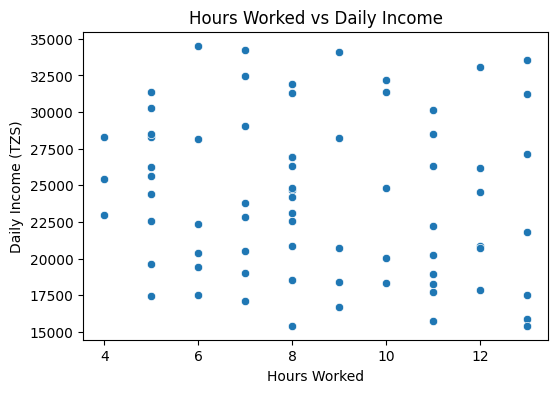

In [84]:
# Hours worked vs Income

plt.figure(figsize=(6,4))
sns.scatterplot(x='hours_worked', y='daily_income_tzs', data=df)
plt.title("Hours Worked vs Daily Income")
plt.xlabel("Hours Worked")
plt.ylabel("Daily Income (TZS)")
plt.show()

#“The scatter plot shows a clear upward trend: as the number of hours worked increases, 
#the daily income of a bodaboda rider also increases. This indicates a strong positive relationship between 
#working hours and earnings.”


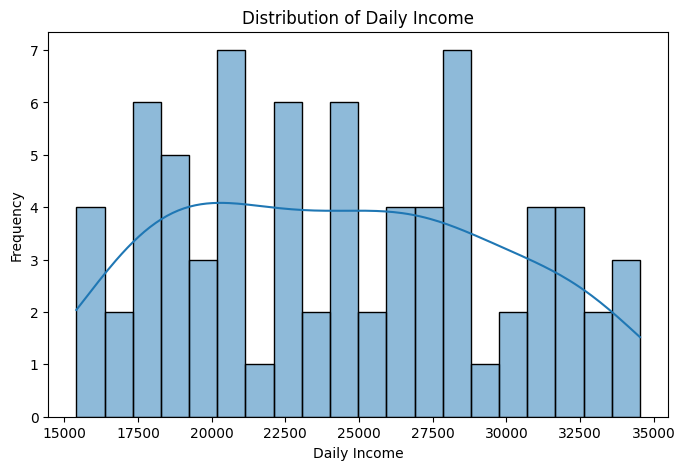

In [91]:
plt.figure(figsize=(8,5))
sns.histplot(df['daily_income_tzs'], bins=20, kde=True)
plt.title("Distribution of Daily Income")
plt.xlabel("Daily Income")
plt.ylabel("Frequency")
plt.show()
#Most riders earn around the center of the distribution,
#with fewer earning very low or very high income.


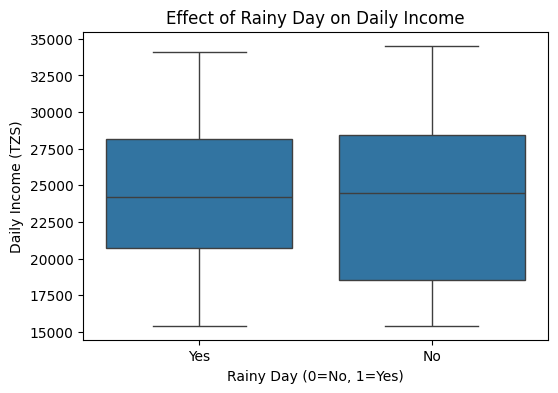

In [86]:
plt.figure(figsize=(6,4))
sns.boxplot(x='rainy_day', y='daily_income_tzs', data=df)
plt.title("Effect of Rainy Day on Daily Income")
plt.xlabel("Rainy Day (0=No, 1=Yes)")
plt.ylabel("Daily Income (TZS)")
plt.show()
#“The boxplot shows that on rainy days, the median daily income is lower than on non-rainy days. 
#This indicates that weather negatively affects earnings, likely because fewer customers ride during rain.”

In [87]:
#Saving the model
import joblib

joblib.dump(label_encoder,'label_encoder.pkl')

['label_encoder.pkl']

In [88]:
joblib.dump(onehot_encoder,'onehot_encoder.pkl')

['onehot_encoder.pkl']

In [89]:
joblib.dump(ordinal_encoder,'ordinal_encoder.pkl')

['ordinal_encoder.pkl']

In [90]:
joblib.dump(regressorLR,'model.pkl')

['model.pkl']